# EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter


In [2]:
# Load the dataset
# data = pd.read_csv('political_bias.csv', dtype=str) dont know why this doesnt work 
data = pd.read_csv('political_bias.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3458 non-null   object
 1   Link    3458 non-null   object
 2   Text    3397 non-null   object
 3   Source  3458 non-null   object
 4   Bias    3458 non-null   object
dtypes: object(5)
memory usage: 135.2+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title      0
Link       0
Text      61
Source     0
Bias       0
dtype: int64


In [5]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   object
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(5)
memory usage: 159.2+ KB


In [6]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   object
 1   Link    2765 non-null   object
 2   Text    2765 non-null   object
 3   Source  2765 non-null   object
 4   Bias    2765 non-null   object
dtypes: object(5)
memory usage: 129.6+ KB


In [7]:
# Clean the data to fix encoding issues and remove unwanted characters
def fix_encoding_and_special_chars(text):
    # Fix common encoding issues
    text = text.replace('â€™', '').replace('â€œ', '"').replace('â€', '"').replace('â€™','"').replace('â€˜','"')  # Replace known encoding issues
    
    # Remove special characters and numbers using regular expression (keeps only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

# Apply the function to clean the cols
data['Title'] = data['Title'].apply(fix_encoding_and_special_chars)
data['Text'] = data['Text'].apply(fix_encoding_and_special_chars)
data['Source'] = data['Source'].apply(fix_encoding_and_special_chars)
data['Bias'] = data['Bias'].apply(fix_encoding_and_special_chars)

# Convert the data to strings 
data['Title'] = data['Title'].astype('string')
data['Text'] = data['Text'].astype('string')
data['Link'] = data['Link'].astype('string')
data['Source'] = data['Source'].astype('string')
data['Bias'] = data['Bias'].astype('string')

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   string
 1   Link    2765 non-null   string
 2   Text    2765 non-null   string
 3   Source  2765 non-null   string
 4   Bias    2765 non-null   string
dtypes: string(5)
memory usage: 129.6 KB


In [8]:
# Show the first few rows of the dataset
data.head()

,Title,Link,Text,Source,Bias
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right


In [9]:
# Summary statistics of numerical columns (if any)
data.describe()

,Title,Link,Text,Source,Bias
count,2765,2765,2765,2765,2765
unique,2511,2280,2434,21,5
top,Trumps Supposed Unity Message Is a Gloating Th...,https://www.thenation.com/article/politics/dem...,A new bill in Mississippi could turn bounty hu...,Alternet,left
freq,7,7,5,596,1376


In [10]:
# noticed that not all rows are unique, so we will drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

In [11]:
# Verify by checking the data info
data.describe()

,Title,Link,Text,Source,Bias
count,2224,2224,2224,2224,2224
unique,2224,2224,2224,21,5
top,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,Alternet,left
freq,1,1,1,483,1150


## Distribution of Bias over dataset

In [12]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
left          1150
right          382
lean left      305
center         202
lean right     185
Name: count, dtype: Int64


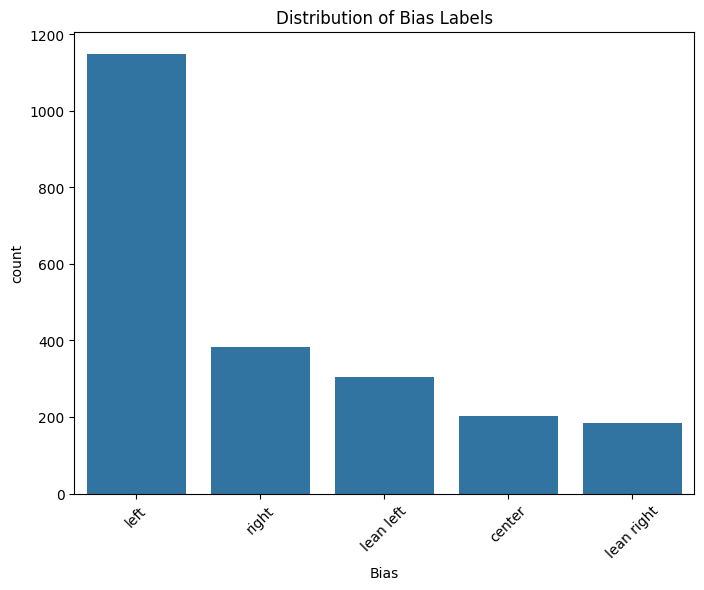

In [13]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

## Analyse Text Content 

In [14]:
import re
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

# Ensure required resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')

# Define a set of English stopwords
stop_words = set(stopwords.words('english'))

def clean_and_stem_text(text):
    """
    Clean, remove stopwords, and stem text.
    
    Steps:
    1. Convert text to lowercase.
    2. Remove punctuation and non-alphabetic characters.
    3. Tokenize the text.
    4. Remove stopwords.
    5. Apply stemming on each token.
    6. Rejoin tokens into a cleaned string.
    """
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and non-letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text into words
    tokens = nltk.word_tokenize(text)
    
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    
    # Initialize the stemmer
    stemmer = PorterStemmer()
    
    # Stem each token
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    # Rejoin the stemmed tokens into a single string
    cleaned_text = ' '.join(stemmed_tokens)
    return cleaned_text

# Example usage:
sample_text = "Running, runners ran and are running quickly! But they weren't too happy about it."
print(clean_and_stem_text(sample_text))

run runner ran run quickli werent happi


[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Apply the clean_text function to the 'Text' column
data['cleaned_text'] = data['Text'].apply(clean_and_stem_text)

# Most common words (excluding stopwords)
words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,trump,13068
1,said,8341
2,presid,5592
3,state,4520
4,us,4118
5,peopl,3598
6,would,3336
7,also,3076
8,one,3017
9,year,2835


In [16]:
total_words = sum(word_counts.values())
print(total_words)

850586


In [17]:
common_words_df['Percentage'] = (common_words_df['Frequency'] / total_words) * 100

In [18]:
common_words_df.head(20)

,Word,Frequency,Percentage
0,trump,13068,1.536353
1,said,8341,0.980618
2,presid,5592,0.657429
3,state,4520,0.531398
4,us,4118,0.484137
5,peopl,3598,0.423002
6,would,3336,0.392200
7,also,3076,0.361633
8,one,3017,0.354697
9,year,2835,0.333300


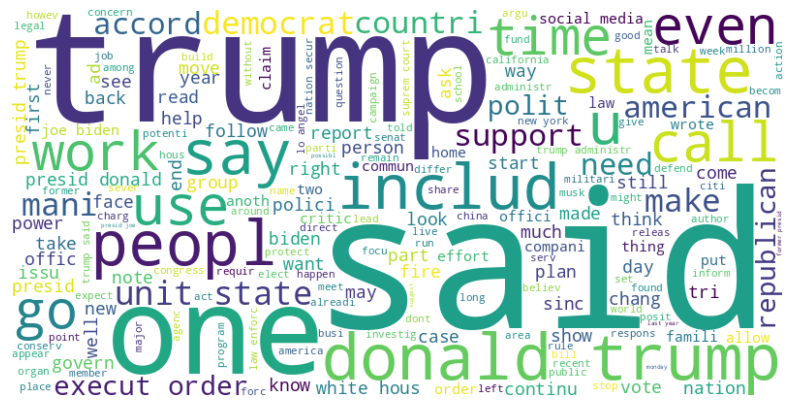

In [19]:
# Generate a wordcloud
text = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## Analyse Length

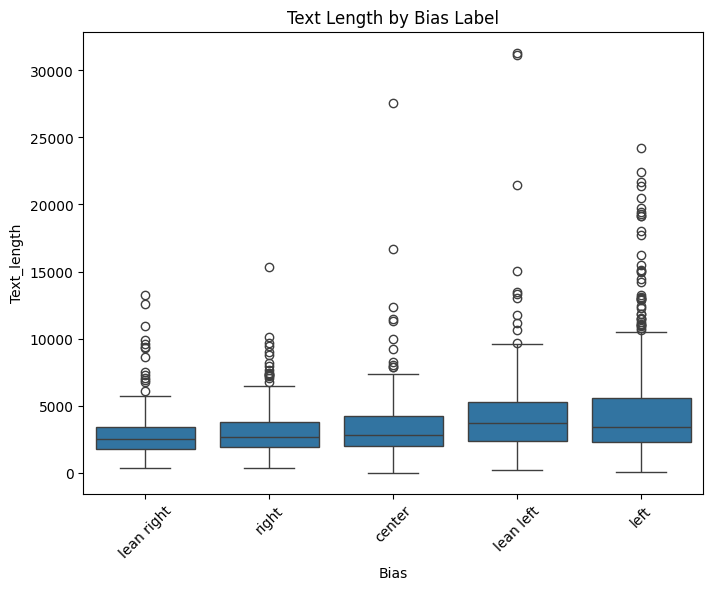

In [20]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

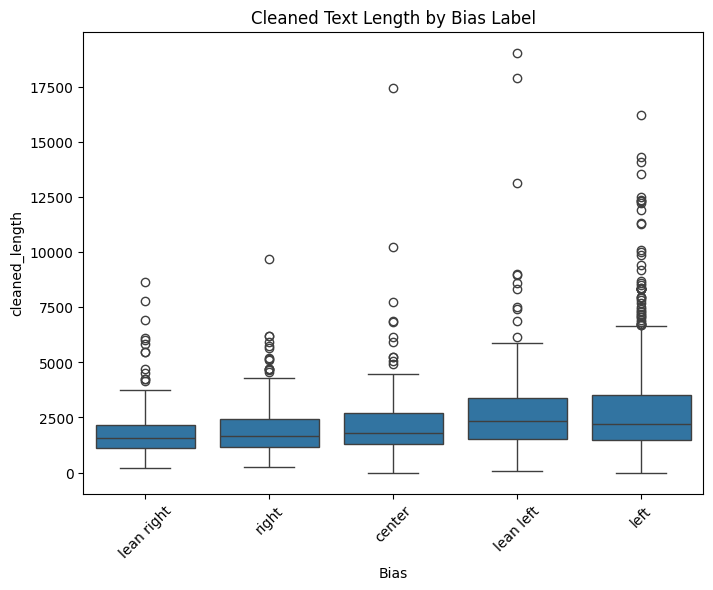

In [21]:
# Investigating length of cleaned articles by bias
data['cleaned_length'] = data['cleaned_text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='cleaned_length')
plt.title('Cleaned Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

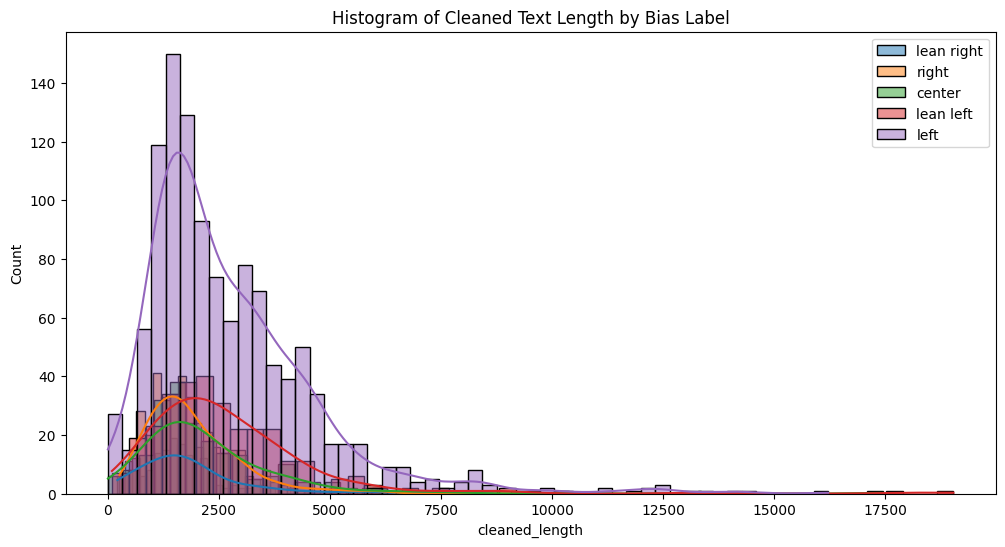

In [22]:
plt.figure(figsize=(12,6))
for bias_label in data['Bias'].unique():
    sns.histplot(data[data['Bias'] == bias_label]['cleaned_length'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Cleaned Text Length by Bias Label")
plt.show()

In [ ]:
# Query: Are all the outliers for bias = left from the same source?
# Filter DataFrame for bias "left"
data_left = data[data['Bias'] == 'left'].copy()

# Compute text length if not already computed (adjust the column name as needed)
data_left['text_length'] = data_left['Text'].apply(len)

# Use the IQR method to identify outliers in text length
Q1 = data_left['text_length'].quantile(0.25)
Q3 = data_left['text_length'].quantile(0.75)
IQR = Q3 - Q1
# Here, we consider as outliers those with text length greater than Q3 + 1.5 * IQR.
outlier_threshold = Q3 + 1.5 * IQR

# Extract outlier rows
outliers = data_left[data_left['text_length'] > outlier_threshold]

# Display the sources and text lengths for the outliers
print("Outliers (text length > {:.0f}):".format(outlier_threshold))
#print(outliers[['Source', 'text_length']].sort_values(by='text_length', ascending=False))

# Additionally, count the occurrence of sources among the outliers to see if one source dominates
print("\nCount of outliers by source:")
print(outliers['Source'].value_counts())

# Create a boolean column that flags outliers based on text length
data_left['is_outlier'] = data_left['text_length'] > outlier_threshold

# Group by source and calculate the percentage of outlier rows
# The mean of the boolean column gives the fraction of outliers for that group
source_outlier_pct = data_left.groupby('Source')['is_outlier'].mean() * 100

# Print the percentage of outliers for each source, sorted in descending order
print("Percentage of outliers by source (for bias 'left'):")
print(source_outlier_pct.sort_values(ascending=False))

Outliers (text length > 10464):

Count of outliers by source:
Source
Apnews         11
TheNation       9
Alternet        8
MotherJones     7
Huffpost        4
Name: count, dtype: Int64
Percentage of outliers by source (for bias 'left'):
Source
TheNation        29.032258
MotherJones      11.864407
Huffpost          3.125000
Apnews            2.820513
Alternet          1.656315
TheDailyBeast     0.000000
Name: is_outlier, dtype: float64


In [ ]:
# Query: what % of each source is considered an outlier? vs entire corpus 
# Create a temporary copy of the original DataFrame
df_temp = data.copy()

# Compute text length for each article (assuming the text column is named 'text')
df_temp['Text_length'] = df_temp['Text'].apply(len)

# Calculate the IQR for text_length to determine the outlier threshold
Q1 = df_temp['Text_length'].quantile(0.25)
Q3 = df_temp['Text_length'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# Define a function to compute the percentage of outlier rows for a series of text lengths
def compute_outlier_percentage(series):
    return (series > outlier_threshold).mean() * 100

# Group by 'source' and apply the outlier percentage function on the text_length column
source_outlier_pct = df_temp.groupby('Source')['Text_length'].agg(compute_outlier_percentage)

# Print the percentage of outliers by source, sorted in descending order
print("Percentage of outliers by source (for the entire DataFrame):")
print(source_outlier_pct.sort_values(ascending=False))

Percentage of outliers by source (for the entire DataFrame):
Source
TheNation                   35.483871
TheDispatch                 29.411765
MotherJones                 22.033898
usatoday                     7.216495
Huffpost                     7.031250
reason                       6.818182
TheFreePress                 5.555556
Apnews                       4.615385
nbcnews                      3.571429
BlazeMedia                   2.857143
npr                          2.666667
abcnews                      2.597403
TheFederalist                2.500000
Alternet                     2.484472
IndependentJournalReview     1.388889
StraightArrowNews            1.234568
BreitBart                    0.452489
NewYorkPost                  0.000000
TheDailyBeast                0.000000
TheWashingtonFreeBeacon      0.000000
cnbc                         0.000000
Name: Text_length, dtype: float64


In [23]:
# Group by 'Bias' and get text length analysis for each group
grouped_description = data.groupby('Bias').describe()

# Display the result
print(grouped_description)

           Text_length                                                    \
                 count         mean          std    min      25%     50%   
Bias                                                                       
center           202.0  3550.292079  2859.330496    3.0  2018.75  2785.5   
lean left        305.0  4288.947541  3396.918928  177.0  2357.00  3671.0   
lean right       185.0  2988.097297  2169.002348  348.0  1790.00  2499.0   
left            1150.0  4253.715652  3020.431239   15.0  2268.75  3421.0   
right            382.0  3030.094241  1757.916638  363.0  1886.75  2625.0   

                             cleaned_length                                   \
                75%      max          count         mean          std    min   
Bias                                                                           
center      4218.25  27565.0          202.0  2253.059406  1777.694613    0.0   
lean left   5289.00  31337.0          305.0  2697.180328  2071.081667  

In [24]:
## i think we should drop the outlier data. wdyt? can wait till new data is in 

In [25]:
import scipy.stats as stats

# Perform ANOVA to compare the means of cleaned_length across different Bias categories
f_stat, p_val = stats.f_oneway(data[data['Bias'] == 'lean right']['cleaned_length'],
                                data[data['Bias'] == 'right']['cleaned_length'],
                                data[data['Bias'] == 'center']['cleaned_length'],
                                data[data['Bias'] == 'lean left']['cleaned_length'],
                                data[data['Bias'] == 'left']['cleaned_length'])

print("ANOVA p-value:", p_val)

#statistically significant difference in the means of text lengths between the different bias categories

ANOVA p-value: 9.31454701641459e-19


In [26]:
# Perform Levene's test to compare the variances of cleaned_length across different Bias categories
w_stat, p_val_levene = stats.levene(data[data['Bias'] == 'lean right']['cleaned_length'],
                                    data[data['Bias'] == 'right']['cleaned_length'],
                                    data[data['Bias'] == 'center']['cleaned_length'],
                                    data[data['Bias'] == 'lean left']['cleaned_length'],
                                    data[data['Bias'] == 'left']['cleaned_length'])

print("Levene's Test p-value:", p_val_levene)

#statistically significant difference in the variance of text lengths between the different bias categories

Levene's Test p-value: 5.484740696008896e-12


## Analyse Distribution of Vocabulary

In [27]:
from collections import Counter

# Dictionary to store unique word count for each Bias label
unique_word_counts = {}

# Iterate through unique Bias labels
for bias_label in data['Bias'].unique():
    # Concatenate all cleaned_text for the current bias label
    all_text = " ".join(data[data['Bias'] == bias_label]['cleaned_text'])
    
    # Get unique words
    unique_words = set(all_text.split())
    
    # Store the count in the dictionary
    unique_word_counts[bias_label] = len(unique_words)

# Sort the dictionary by values in descending order
sorted_unique_word_counts = dict(sorted(unique_word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the sorted dictionary
print(sorted_unique_word_counts)

{'left': 26323, 'lean left': 9932, 'right': 9703, 'lean right': 7883, 'center': 7827}


In [28]:
# Function to compute unique word count for each row
def unique_word_count(text):
    return len(set(str(text).split()))

# Add a new column for per-row unique word count
data['unique_word_count'] = data['cleaned_text'].apply(unique_word_count)

# Display the first few rows of the updated DataFrame
data.head()

,Title,Link,Text,Source,Bias,cleaned_text,Text_length,cleaned_length,unique_word_count
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right,day inaugur would shock learn donald trump wal...,6060,3514,330
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right,welcom back techn star trek writer got around ...,12568,7792,668
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right,fire still rage lo angel area ive torn whether...,2049,1253,162
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right,whether roger toni soprano old suggest buy lan...,4263,2699,280
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right,happi friday anyon wonder belgium food agenc o...,452,306,48


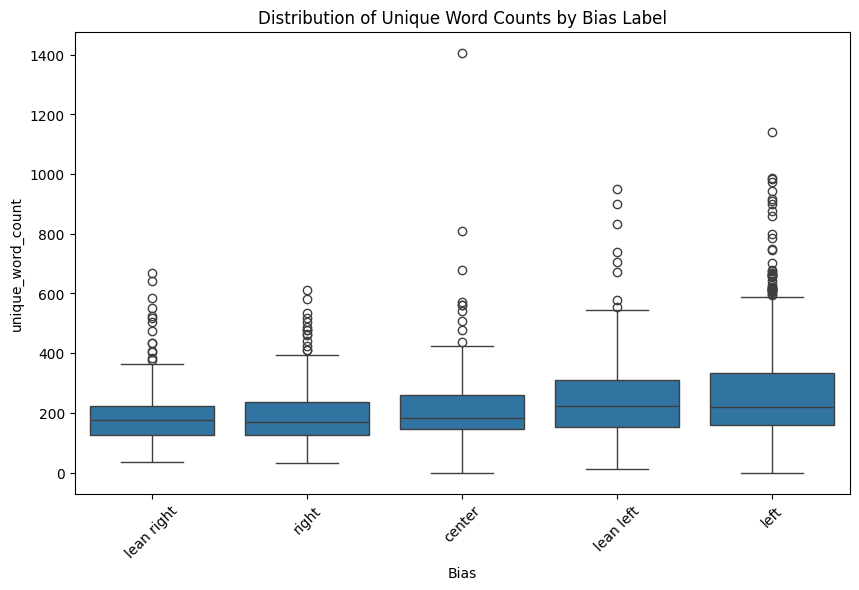

In [29]:
# Visualize distributions
plt.figure(figsize=(10,6))
sns.boxplot(x=data['Bias'], y=data['unique_word_count'])
plt.xticks(rotation=45)
plt.title("Distribution of Unique Word Counts by Bias Label")
plt.show()

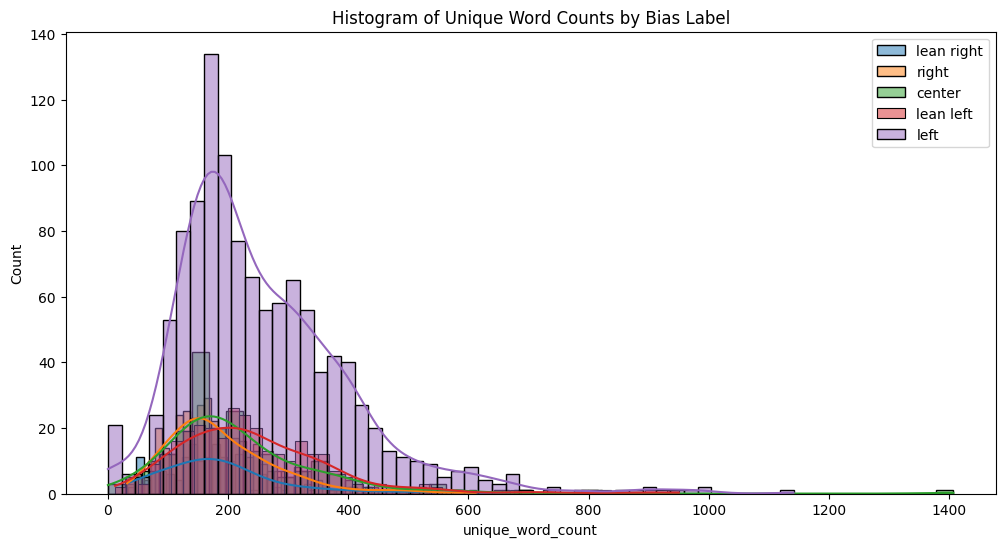

In [30]:
plt.figure(figsize=(12,6))
for bias_label in data['Bias'].unique():
    sns.histplot(data[data['Bias'] == bias_label]['unique_word_count'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Unique Word Counts by Bias Label")
plt.show()

## Analyse Source

Source
Alternet                    483
Apnews                      390
BreitBart                   221
NewYorkPost                 132
Huffpost                    128
usatoday                     97
reason                       88
StraightArrowNews            81
abcnews                      77
npr                          75
IndependentJournalReview     72
MotherJones                  59
TheDailyBeast                59
nbcnews                      56
TheFederalist                40
TheFreePress                 36
BlazeMedia                   35
cnbc                         33
TheNation                    31
TheDispatch                  17
TheWashingtonFreeBeacon      14
Name: count, dtype: Int64


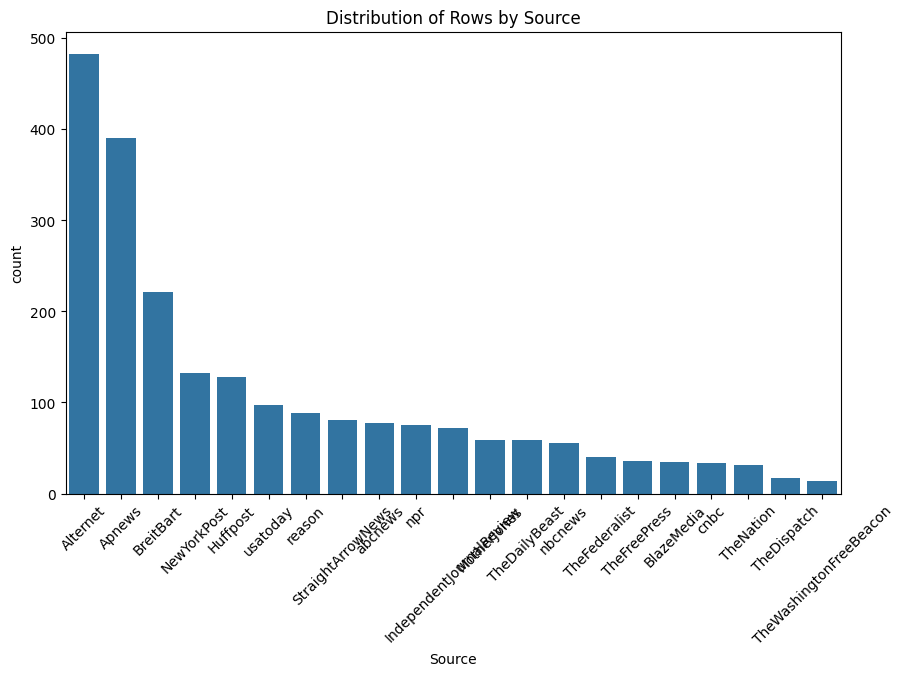

In [31]:
## check distribution of news sources
source_counts = data['Source'].value_counts()

# Print the distribution
print(source_counts)

# Plot the distribution using a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Source', order=source_counts.index)
plt.title('Distribution of Rows by Source')
plt.xticks(rotation=45)
plt.show()

Bias                      center  lean left  lean right  left  right
Source                                                              
Alternet                       0          0           0   483      0
Apnews                         0          0           0   390      0
BreitBart                      0          0           0     0    221
NewYorkPost                    0          0         132     0      0
Huffpost                       0          0           0   128      0
usatoday                       0         97           0     0      0
reason                        88          0           0     0      0
StraightArrowNews             81          0           0     0      0
abcnews                        0         77           0     0      0
npr                            0         75           0     0      0
IndependentJournalReview       0          0           0     0     72
MotherJones                    0          0           0    59      0
TheDailyBeast                  0  

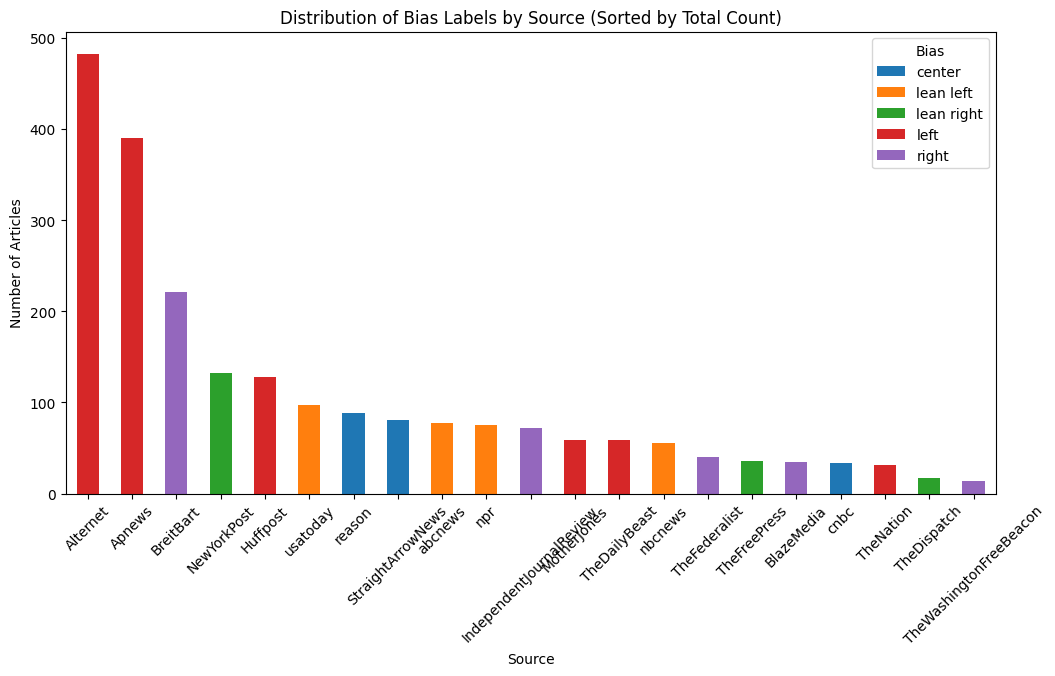

In [32]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Sum the counts for each source and sort by the total count
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the sorted distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked bar plot
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (Sorted by Total Count)')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

Bias                      center  lean left  lean right   left  right
Source                                                               
Alternet                     0.0        0.0         0.0  100.0    0.0
TheFederalist                0.0        0.0         0.0    0.0  100.0
reason                     100.0        0.0         0.0    0.0    0.0
npr                          0.0      100.0         0.0    0.0    0.0
nbcnews                      0.0      100.0         0.0    0.0    0.0
cnbc                       100.0        0.0         0.0    0.0    0.0
abcnews                      0.0      100.0         0.0    0.0    0.0
TheWashingtonFreeBeacon      0.0        0.0         0.0    0.0  100.0
TheNation                    0.0        0.0         0.0  100.0    0.0
TheFreePress                 0.0        0.0       100.0    0.0    0.0
TheDispatch                  0.0        0.0       100.0    0.0    0.0
Apnews                       0.0        0.0         0.0  100.0    0.0
TheDailyBeast       

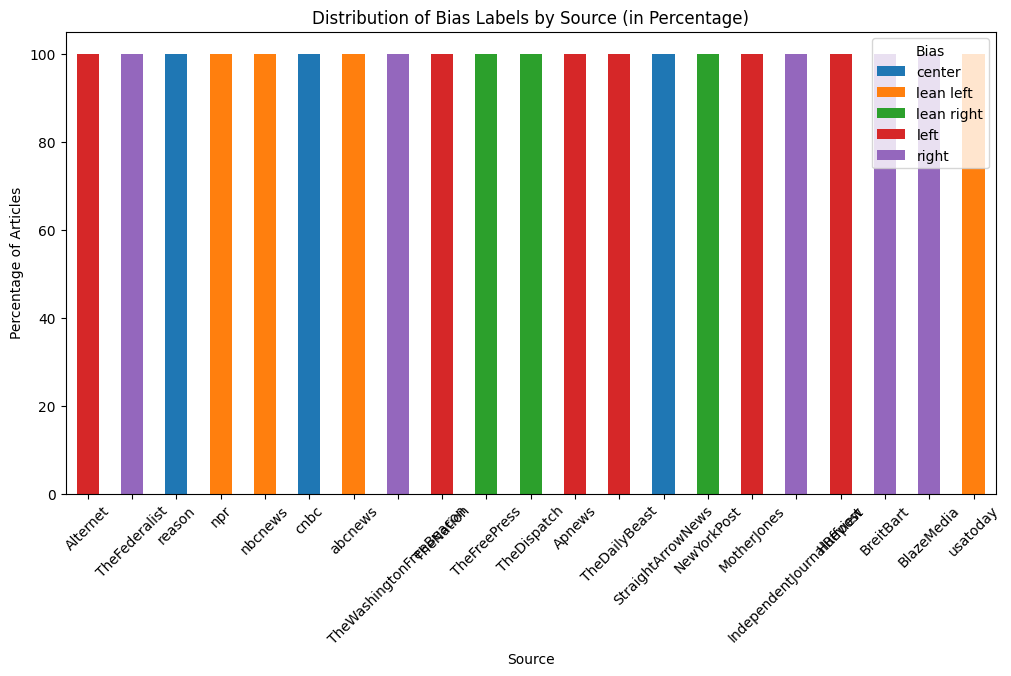

In [33]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Normalize the counts by dividing by the row sums (to get percentages)
bias_distribution_by_source = bias_distribution_by_source.div(bias_distribution_by_source.sum(axis=1), axis=0) * 100

# Sort by the total percentage (optional, to maintain consistency)
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the normalized distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked column chart in percentages
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (in Percentage)')
plt.xlabel('Source')
plt.ylabel('Percentage of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

# all sources produce only one type of bias, hence source is a strong predictor of bias

In [34]:
# Create a set of unique words from the 'Source' column
unique_words = set(" ".join(data['Source']).split())

# Remove 'reason' if it exists in the set
unique_words.discard('reason')

# Function to remove words in unique_words from text
def strip_words(text, words_to_remove):
    return " ".join([word for word in text.split() if word not in words_to_remove])

# Create a new DataFrame and apply the stripping function
df_stripped_source_names = data.copy()
df_stripped_source_names['stripped_text'] = df_stripped_source_names['cleaned_text'].apply(lambda x: strip_words(str(x), unique_words))

# Add stripped_len column for the length of stripped_text
df_stripped_source_names['stripped_len'] = df_stripped_source_names['stripped_text'].apply(lambda x: len(x.split()))

# Add a new column for the difference between text_length and stripped_len
df_stripped_source_names['text_length_diff'] = df_stripped_source_names['Text_length'] - df_stripped_source_names['stripped_len']

# Display the new DataFrame
df_stripped_source_names.head()

,Title,Link,Text,Source,Bias,cleaned_text,Text_length,cleaned_length,unique_word_count,stripped_text,stripped_len,text_length_diff
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right,day inaugur would shock learn donald trump wal...,6060,3514,330,day inaugur would shock learn donald trump wal...,535,5525
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right,welcom back techn star trek writer got around ...,12568,7792,668,welcom back techn star trek writer got around ...,1171,11397
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right,fire still rage lo angel area ive torn whether...,2049,1253,162,fire still rage lo angel area ive torn whether...,192,1857
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right,whether roger toni soprano old suggest buy lan...,4263,2699,280,whether roger toni soprano old suggest buy lan...,410,3853
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right,happi friday anyon wonder belgium food agenc o...,452,306,48,happi friday anyon wonder belgium food agenc o...,48,404


In [35]:
unique_words

{'Alternet',
 'Apnews',
 'BlazeMedia',
 'BreitBart',
 'Huffpost',
 'IndependentJournalReview',
 'MotherJones',
 'NewYorkPost',
 'StraightArrowNews',
 'TheDailyBeast',
 'TheDispatch',
 'TheFederalist',
 'TheFreePress',
 'TheNation',
 'TheWashingtonFreeBeacon',
 'abcnews',
 'cnbc',
 'nbcnews',
 'npr',
 'usatoday'}

In [36]:
# Display the top 50 rows with selected columns
df_stripped_source_names[['cleaned_text', 'Text_length', 'stripped_text', 'stripped_len']].head(50)

,cleaned_text,Text_length,stripped_text,stripped_len
0,day inaugur would shock learn donald trump wal...,6060,day inaugur would shock learn donald trump wal...,535
1,welcom back techn star trek writer got around ...,12568,welcom back techn star trek writer got around ...,1171
2,fire still rage lo angel area ive torn whether...,2049,fire still rage lo angel area ive torn whether...,192
3,whether roger toni soprano old suggest buy lan...,4263,whether roger toni soprano old suggest buy lan...,410
4,happi friday anyon wonder belgium food agenc o...,452,happi friday anyon wonder belgium food agenc o...,48
5,american celebr end prosecutori nightmar presi...,2893,american celebr end prosecutori nightmar presi...,266
6,newli inaugur presid donald trump made good pr...,2528,newli inaugur presid donald trump made good pr...,241
7,former congresswoman liz cheney rwyo respond i...,1799,former congresswoman liz cheney rwyo respond i...,181
8,former presid joe biden issu controversi pardo...,2556,former presid joe biden issu controversi pardo...,249
9,detroit pastor deliv rous benedict close presi...,2534,detroit pastor deliv rous benedict close presi...,253


In [37]:
#pip install pyldavis

In [38]:
import numpy as np
import nltk
from nltk.corpus import stopwords
import gensim
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim
import pandas as pd

#nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop = set(stopwords.words('english'))

def preprocess_text(text):
    corpus = []
    lem = WordNetLemmatizer()
    for news in text:
        words = [w for w in word_tokenize(news) if w.lower() not in stop]
        words = [lem.lemmatize(w) for w in words if len(w) > 2]
        corpus.append(words)
    return corpus

def get_lda_by_bias(data):
    lda_models = {}
    bow_corpus_dict = {}

    for bias_label in data['Bias'].unique():
        subset = data[data['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
        corpus = preprocess_text(subset)

        dic = gensim.corpora.Dictionary(corpus)
        bow_corpus = [dic.doc2bow(doc) for doc in corpus]

        lda_model = gensim.models.LdaMulticore(
            bow_corpus, num_topics=4, id2word=dic, passes=10, workers=2
        )

        lda_models[bias_label] = lda_model
        bow_corpus_dict[bias_label] = (bow_corpus, dic)

    return lda_models, bow_corpus_dict

def plot_lda_vis(lda_model, bow_corpus, dic):
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dic)
    return vis

def show_topics_by_bias(lda_models):
    for bias_label, lda_model in lda_models.items():
        print(f"\nTopics for Bias: {bias_label}")
        topics = lda_model.print_topics(num_words=5)
        for topic in topics:
            print(topic)

[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
lda_models, bow_corpus_dict = get_lda_by_bias(data)

In [40]:
bias_label = "left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=5504) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=5504) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=5504) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=5504) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foong

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.077967  0.033436       1        1  35.660855
0      0.074026  0.022517       2        1  28.699579
1      0.058848 -0.059590       3        1  26.546178
3     -0.210841  0.003638       4        1   9.093388, topic_info=         Term        Freq        Total Category  logprob  loglift
12047     que  780.000000   780.000000  Default  30.0000  30.0000
2644     gaza  301.000000   301.000000  Default  29.0000  29.0000
11775     del  272.000000   272.000000  Default  28.0000  28.0000
2655   israel  309.000000   309.000000  Default  27.0000  27.0000
12014     por  267.000000   267.000000  Default  26.0000  26.0000
...       ...         ...          ...      ...      ...      ...
444      forc   78.121352   401.779630   Topic4  -6.2997   0.7600
1373   sunday   72.843497   245.044956   Topic4  -6.3696   1.1845
472       one   82.529811  1586.870117   Topic4  -6.2448  -0.5587
476      part   76.885133   557.566117   Topic4  -6.3156   0.4164
38      first   77.243564  1344.055232   Topic4  -6.3110  -0.4589

[363 rows x 6 columns], token_table=       Topic      Freq    Term
term                          
11190      3  0.958244   abbot
4072       1  0.158688   abort
4072       2  0.028852   abort
4072       3  0.811475   abort
4072       4  0.003607   abort
...      ...       ...     ...
21602      2  0.931265  yeldel
6717       2  0.966612    yoon
6717       3  0.017900    yoon
21155      3  0.967885    yost
11359      3  0.944743     zyn

[808 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2, 4])

In [41]:
bias_label = "lean left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.023845 -0.024626       1        1  37.418023
1     -0.062774 -0.047305       2        1  30.666983
2      0.102875 -0.020041       3        1  20.990948
0     -0.016255  0.091971       4        1  10.924045, topic_info=         Term         Freq        Total Category  logprob  loglift
161     trump  1777.000000  1777.000000  Default  30.0000  30.0000
115    presid   904.000000   904.000000  Default  29.0000  29.0000
359     order   504.000000   504.000000  Default  28.0000  28.0000
278      fire   541.000000   541.000000  Default  27.0000  27.0000
899     gener   179.000000   179.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
6        also    46.328380   518.231644   Topic4  -5.6824  -0.2005
483     would    40.714238   466.679234   Topic4  -5.8116  -0.2249
449      time    39.253205   353.957191   Topic4  -5.8481   0.0151
278      fire    36.839873   541.053576   Topic4  -5.9116  -0.4727
191  american    35.918628   234.505768   Topic4  -5.9369   0.3380

[334 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
487       1  0.301278     accord
487       2  0.315903     accord
487       3  0.295428     accord
487       4  0.087751     accord
5342      1  0.020052        acr
...     ...       ...        ...
8599      3  0.915716  youngblut
5026      2  0.945777  zelenskyy
2573      2  0.761219        zoo
2573      3  0.015224        zoo
2573      4  0.213141        zoo

[647 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 3, 1])

In [42]:
bias_label = "center"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.055430 -0.059497       1        1  33.271244
1     -0.037082  0.015280       2        1  25.639248
2      0.092823 -0.029178       3        1  25.358000
3     -0.000312  0.073396       4        1  15.731508, topic_info=          Term        Freq       Total Category  logprob  loglift
28        musk  115.000000  115.000000  Default  30.0000  30.0000
10       trump  853.000000  853.000000  Default  29.0000  29.0000
355     tiktok  114.000000  114.000000  Default  28.0000  28.0000
1069    tariff   78.000000   78.000000  Default  27.0000  27.0000
5375   hegseth   65.000000   65.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
147     includ   25.467383  170.776989   Topic4  -6.0418  -0.0535
158       like   25.532567  176.039834   Topic4  -6.0393  -0.0813
187      peopl   25.193225  209.639189   Topic4  -6.0526  -0.2693
263      would   25.856668  329.551874   Topic4  -6.0266  -0.6957
59    american   24.623516  181.894957   Topic4  -6.0755  -0.1502

[350 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
5658      1  0.947117      abbott
50        1  0.277486   administr
50        2  0.443004   administr
50        3  0.087627   administr
50        4  0.194727   administr
...     ...       ...         ...
264       2  0.298179        year
264       3  0.173938        year
264       4  0.173938        year
2282      2  0.165588  zuckerberg
2282      3  0.786545  zuckerberg

[660 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])

In [43]:
bias_label = "lean right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.097840 -0.035457       1        1  46.163635
0     -0.032045 -0.005365       2        1  28.038477
1     -0.063180 -0.056203       3        1  17.391522
3     -0.002615  0.097025       4        1   8.406366, topic_info=        Term        Freq       Total Category  logprob  loglift
750   school   75.000000   75.000000  Default  30.0000  30.0000
1103    said  486.000000  486.000000  Default  29.0000  29.0000
508     fire  113.000000  113.000000  Default  28.0000  28.0000
213     post  200.000000  200.000000  Default  27.0000  27.0000
1299  pardon  129.000000  129.000000  Default  26.0000  26.0000
...      ...         ...         ...      ...      ...      ...
344     also   11.071880  177.873933   Topic4  -5.9871  -0.3005
273    state   10.810495  191.220086   Topic4  -6.0110  -0.3967
160     make   10.063569  103.499304   Topic4  -6.0826   0.1455
131   includ   10.127185  127.549185   Topic4  -6.0763  -0.0571
65       day   10.071942  154.682076   Topic4  -6.0818  -0.2554

[325 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
5231      1  0.916545   abort
5231      2  0.076379   abort
1541      1  0.307398  accord
1541      2  0.283752  accord
1541      3  0.338926  accord
...     ...       ...     ...
318       4  0.105756    year
320       1  0.216041    york
320       2  0.194437    york
320       3  0.432082    york
320       4  0.129625    york

[576 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2, 4])

In [44]:
bias_label = "right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.004470  0.037854       1        1  36.843596
3      0.012736  0.057040       2        1  25.549232
0     -0.082581 -0.035876       3        1  21.024542
2      0.065375 -0.059018       4        1  16.582630, topic_info=            Term        Freq       Total Category  logprob  loglift
124       pardon  221.000000  221.000000  Default  30.0000  30.0000
1255     hegseth  119.000000  119.000000  Default  29.0000  29.0000
1099     confirm  162.000000  162.000000  Default  28.0000  28.0000
1148       senat  248.000000  248.000000  Default  27.0000  27.0000
400   california  109.000000  109.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
43        donald   45.707148  349.851495   Topic4  -5.9788  -0.2384
111         news   46.768294  497.546604   Topic4  -5.9559  -0.5677
174         unit   42.268975  280.984024   Topic4  -6.0570  -0.0974
4       american   41.978931  352.357065   Topic4  -6.0639  -0.3307
296      support   41.458613  197.809018   Topic4  -6.0764   0.2342

[359 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
190       1  0.658985     action
190       2  0.141211     action
190       3  0.133366     action
190       4  0.062760     action
393       1  0.144312       adam
...     ...       ...        ...
186       1  0.400537       year
186       2  0.214688       year
186       3  0.205075       year
186       4  0.182645       year
5970      4  0.959977  youngblut

[674 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 1, 3])

## Conclusion

conc of distribution:
- left is heavily oversampled, when assessing accuracy, need to be careful. AOC, one vs many etc methods can be used.

conclusion of checking text length: 
- long tail of outliers for left articles
- difference in mean length and variances between each bias is significant (anova and levene tests are significant at p<0.05) ## double check this later 
- from box whisker and histogram, unlikely to be a strong predictor

conc of analysis of vocabularly: 
- from box whisker and histogram, unlikely to be a strong predictor

anaysis of source: 
- Of the given sources, unexpectedly, source maps to Bias 1 to 1